Processing image size: 26x43
Running Mean Shift Clustering (Color Only)...
Iteration 1/15
Iteration 2/15
Iteration 3/15
Iteration 4/15
Iteration 5/15
Iteration 6/15
Iteration 7/15
Iteration 8/15
Iteration 9/15
Iteration 10/15
Iteration 11/15
Iteration 12/15
Iteration 13/15
Iteration 14/15
Iteration 15/15
Mode seeking finished in 1.00 seconds.
Assigning clusters based on converged modes...
Total clusters found: 69


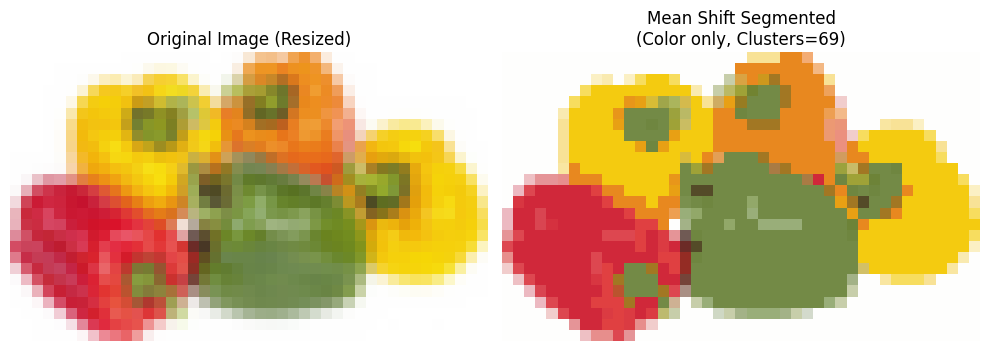

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform
from skimage.util import img_as_float
import time

# Load and Preprocess Image

try:
    img = plt.imread('peppers.jpeg')
except FileNotFoundError:
    img = data.astronaut()

scale = 0.15  # Keep 15% of original size
img = transform.rescale(img, scale, channel_axis=2, anti_aliasing=True)
img = img_as_float(img) # Ensure 0.0 to 1.0 range 
rows, cols, ch = img.shape
print(f"Processing image size: {rows}x{cols}")

# Reshape image into Nx3 array (pixels)
pixels = img.reshape(-1, 3)
N = pixels.shape[0]

#Set Mean Shift parameters

hs = 0.1        # Color bandwidth (distance threshold)
max_iters = 15
threshold = 1e-3

# Mean Shift Mode-Seeking

modes = pixels.copy() # Start each pixel at its own initial location

print('Running Mean Shift Clustering (Color Only)...')
start_time = time.time()

for iteration in range(max_iters):
    print(f"Iteration {iteration+1}/{max_iters}")
    max_shift_iter = 0.0
    
    # Iterate over every pixel/mode
    for i in range(N):
        current_mode = modes[i]
        
        dists = np.linalg.norm(pixels - current_mode, axis=1)
        
        # Find pixels within bandwidth (hs)
        mask = dists < hs
        neighbors = pixels[mask]
        
        # Compute mean of neighbors
        if len(neighbors) > 0:
            new_point = np.mean(neighbors, axis=0)
        else:
            new_point = current_mode
            
        # Update shift
        shift = np.linalg.norm(new_point - current_mode)
        modes[i] = new_point
        
        if shift > max_shift_iter:
            max_shift_iter = shift
            
    # Check global convergence for this iteration
    if max_shift_iter < threshold:
        print("Converged early.")
        break

print(f"Mode seeking finished in {time.time() - start_time:.2f} seconds.")

# Group points that converge to the same mode

print("Assigning clusters based on converged modes...")

cluster_labels = np.zeros(N, dtype=int)
cluster_count = 0
modes_final = [] # List to hold unique cluster centers

for i in range(N):
    assigned = False
    current_mode = modes[i]
    
    # Compare current mode to existing final modes
    for j in range(cluster_count):
        # If the mode is very close to an existing cluster center
        if np.linalg.norm(current_mode - modes_final[j]) < 0.02:
            cluster_labels[i] = j
            assigned = True
            break
    
    # If no match found, create new cluster
    if not assigned:
        modes_final.append(current_mode)
        cluster_labels[i] = cluster_count
        cluster_count += 1

modes_final = np.array(modes_final)
print(f"Total clusters found: {cluster_count}")

# Reconstruct segmented image

seg_pixels = np.zeros_like(pixels)

for k in range(cluster_count):
    # Set all pixels in this cluster to the cluster's mean color
    seg_pixels[cluster_labels == k] = modes_final[k]

seg_img = seg_pixels.reshape(rows, cols, 3)

# Display Results

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Original Image (Resized)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(seg_img)
plt.title(f'Mean Shift Segmented\n(Color only, Clusters={cluster_count})')
plt.axis('off')

plt.tight_layout()
plt.show()